# HPO por perfil v7 — búsqueda conjunta de hiperparámetros

Cambios respecto a v6:
- **1 semilla** por config (en lugar de 3) — HPO ~3× más rápido
- **Conservadores**: lambdas reducidos + scoring con CAGR pesado → el agente entra al mercado
- **muy_arriesgado**: lambdas mínimos [0.01, 0.03, 0.06] + reward_scale=20 fijo → maximizar CAGR
- **Filtros MDD**: muy_conservador admite [−6%, −1%], conservador admite [−10%, −3%]

## Imports y utilidades

In [1]:
from __future__ import annotations

import os
import sys
import copy
import json
import time
import random
import inspect
from itertools import product
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from Entrenamiento_SAC import ConfigEntrenamiento, entrenar_sac
from entorno_cartera import EntornoCartera

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"MPS disponible: {torch.backends.mps.is_available()}")


PROJECT_ROOT: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning
PyTorch: 2.10.0
MPS disponible: True


In [2]:
def fijar_semillas(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def encontrar_carpeta_datos() -> Path:
    candidatos = [
        PROJECT_ROOT / "Datos",
        PROJECT_ROOT / "datos",
        PROJECT_ROOT / "datos_procesados",
    ]
    for carpeta in candidatos:
        if carpeta.exists():
            return carpeta
    raise FileNotFoundError("No encuentro la carpeta de datos. Revisa PROJECT_ROOT.")


def cargar_split(carpeta_base: Path, nombre_split: str):
    carpeta_split = carpeta_base / nombre_split.capitalize()
    datos_estado = pd.read_csv(
        carpeta_split / f"datos_estado_{nombre_split}.csv",
        index_col=0, parse_dates=True,
    )
    retornos = pd.read_csv(
        carpeta_split / f"retornos_{nombre_split}.csv",
        index_col=0, parse_dates=True,
    )
    rf_semanal = pd.read_csv(
        carpeta_split / f"rf_semanal_{nombre_split}.csv",
        index_col=0, parse_dates=True,
    ).squeeze("columns")
    return datos_estado, retornos, rf_semanal


def moving_average(x, window=50):
    x = np.asarray(x, dtype=float)
    if window is None or window <= 1 or len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


## Carga de datos

In [3]:
carpeta_datos = encontrar_carpeta_datos()

datos_estado_train, retornos_train, rf_semanal_train = cargar_split(carpeta_datos, "train")
datos_estado_val,   retornos_val,   rf_semanal_val   = cargar_split(carpeta_datos, "validation")

cov_train = pd.read_csv(carpeta_datos / "Train"      / "covarianzas_train.csv",      index_col=0)
cov_val   = pd.read_csv(carpeta_datos / "Validation" / "covarianzas_validation.csv", index_col=0)

print(f"Carpeta datos: {carpeta_datos}")
print(f"Train:      {datos_estado_train.shape}  retornos: {retornos_train.shape}")
print(f"Validation: {datos_estado_val.shape}  retornos: {retornos_val.shape}")
print(f"Cov train: {cov_train.shape} | Cov val: {cov_val.shape}")


Carpeta datos: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/Datos
Train:      (679, 144)  retornos: (679, 16)
Validation: (261, 144)  retornos: (261, 16)
Cov train: (16, 16) | Cov val: (16, 16)


## Configuración global y perfiles

In [4]:
# ------------------------------------------------------------------
# PERFILES
# ------------------------------------------------------------------
PERFILES_RIESGO: Dict[str, float] = {
    "muy_conservador": 0.10,
    "conservador":     0.30,
    "normal":          0.50,
    "arriesgado":      0.70,
    "muy_arriesgado":  0.90,
}

# ------------------------------------------------------------------
# CONFIG BASE — fija para todos los perfiles
# reward_scale se sobreescribe por perfil en run_grid_perfil()
# ------------------------------------------------------------------
BASE_CONFIG: Dict[str, Any] = {
    "semilla":                      43,
    "pasos_totales":                100_000,
    "tamano_buffer":                50_000,
    "tamano_batch":                 256,
    "pasos_warmup":                 1_000,
    "gamma":                        0.99,
    "lr_alpha":                     1e-4,
    "frecuencia_actualizacion":     2,
    "actualizaciones_por_step":     2,
    "reward_scale":                 20.0,   # valor por defecto; se sobreescribe por perfil
    "target_entropy":               -8.0,
    "offset_target_entropy":        0.0,
    "max_concentracion_total_extra": 5.0,
    "ventana_log_recompensa":       500,
    "frecuencia_log":               5_000,
    "frecuencia_snapshot_cartera":  5_000,
}

# ------------------------------------------------------------------
# reward_scale óptimo por perfil (determinado experimentalmente)
# None  → se incluye en el grid del perfil (muy_arriesgado)
# float → se fija antes de lanzar las combinaciones
# ------------------------------------------------------------------
REWARD_SCALE_POR_PERFIL: Dict[str, Optional[float]] = {
    "muy_conservador": 10.0,   # rs=10 claramente mejor
    "conservador":     20.0,   # rs=20 sigue siendo mejor
    "normal":          10.0,   # rs=10 claramente mejor
    "arriesgado":      20.0,   # rs=20 sigue siendo mejor
    "muy_arriesgado":  20.0,   # fijado a 20, igual que arriesgado (v7)
}

# ------------------------------------------------------------------
# CONTROL
# ------------------------------------------------------------------
SEED_BASE = 43
TOP_K     = 3

N_ACTIVOS_TOTALES          = retornos_train.shape[1] + 1
cartera_inicial_validacion = np.zeros(N_ACTIVOS_TOTALES)
cartera_inicial_validacion[-1] = 1.0   # 100% cash — punto de partida neutro

print(f"N_ACTIVOS_TOTALES: {N_ACTIVOS_TOTALES}")
print(f"Pasos de entrenamiento: {BASE_CONFIG['pasos_totales']:,}")
print(f"Perfiles: {list(PERFILES_RIESGO.keys())}")
print(f"reward_scale por perfil: {REWARD_SCALE_POR_PERFIL}")


N_ACTIVOS_TOTALES: 17
Pasos de entrenamiento: 100,000
Perfiles: ['muy_conservador', 'conservador', 'normal', 'arriesgado', 'muy_arriesgado']
reward_scale por perfil: {'muy_conservador': 10.0, 'conservador': 20.0, 'normal': 10.0, 'arriesgado': 20.0, 'muy_arriesgado': 20.0}


## Espacios de búsqueda por perfil

Cada perfil tiene su propio grid.  
Los perfiles conservadores tienen lambdas altas; los arriesgados, bajas.  
`muy_arriesgado` incluye además `reward_scale` en el grid (único perfil con incertidumbre).

In [5]:
# Hiperparámetros de entrenamiento — iguales en todos los perfiles
_TRAIN_HPS: Dict[str, List] = {
    "tau":         [0.02, 0.05],
    "lr_actor":    [1e-4, 3e-4],
    "lr_criticos": [3e-4],
}

# Lambdas específicos por perfil (v7)
# Conservadores: más bajos para que el agente invierta en lugar de ir a cash
# muy_arriesgado: mínimos para no frenar la búsqueda de CAGR
_LAMBDAS_POR_PERFIL: Dict[str, Dict[str, List]] = {
    # mc, c, n usan el mismo grid raw — a igual posición mc > c > n en effective
    # porque factor = (1 - 0.99*riesgo): mc=0.901, c=0.703, n=0.505
    "muy_conservador": {
        "lambda_varianza":    [0.10, 0.15, 0.22],   # effective: [0.090, 0.135, 0.198]
        "lambda_correlacion": [0.05],
    },
    "conservador": {
        "lambda_varianza":    [0.10, 0.15, 0.22],   # effective: [0.070, 0.105, 0.155]
        "lambda_correlacion": [0.05],
    },
    "normal": {
        "lambda_varianza":    [0.10, 0.15, 0.22],   # effective: [0.051, 0.076, 0.111]
        "lambda_correlacion": [0.10],
    },
    "arriesgado": {
        "lambda_varianza":    [0.05, 0.10, 0.15],
        "lambda_correlacion": [0.05],
    
    },
    "muy_arriesgado": {
        "lambda_varianza":    [0.01, 0.03, 0.06],   # v6: [0.05, 0.08, 0.10]
        "lambda_correlacion": [0.02],
        # reward_scale eliminado del grid — fijado a 20.0 en REWARD_SCALE_POR_PERFIL
    },
}


def espacios_busqueda(perfil: str) -> Dict[str, List]:
    """Une los hiperparámetros de entrenamiento con los lambdas del perfil."""
    espacio = copy.deepcopy(_TRAIN_HPS)
    espacio.update(_LAMBDAS_POR_PERFIL[perfil])
    return espacio


# Mostrar número de combinaciones
for perfil in PERFILES_RIESGO:
    esp = espacios_busqueda(perfil)
    n = int(np.prod([len(v) for v in esp.values()]))
    rs = REWARD_SCALE_POR_PERFIL[perfil]
    rs_str = f"rs={rs}" if rs is not None else "rs=grid[10,20]"
    print(f"  {perfil:20s}: {n} combinaciones  {rs_str}  ({list(esp.keys())})")

total_runs = sum(
    int(np.prod([len(v) for v in espacios_busqueda(p).values()]))
    for p in PERFILES_RIESGO
)
segundos_por_run = 540
horas_estimadas  = total_runs * segundos_por_run / 3600
print(f"\nTotal runs: {total_runs}")
print(f"Tiempo estimado (100k pasos): {horas_estimadas:.1f} h  (~{horas_estimadas*60:.0f} min)")


  muy_conservador     : 12 combinaciones  rs=10.0  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  conservador         : 12 combinaciones  rs=20.0  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  normal              : 12 combinaciones  rs=10.0  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  arriesgado          : 12 combinaciones  rs=20.0  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])
  muy_arriesgado      : 12 combinaciones  rs=20.0  (['tau', 'lr_actor', 'lr_criticos', 'lambda_varianza', 'lambda_correlacion'])

Total runs: 60
Tiempo estimado (100k pasos): 9.0 h  (~540 min)


## Funciones de scoring por perfil (v7)

- **muy_conservador**: Sharpe + neg_MDD + CAGR (0.30 / 0.20 / 0.50) — incentiva exposición al mercado
- **conservador**: Sharpe + neg_MDD + CAGR (0.25 / 0.15 / 0.60) — idem, más peso en retorno
- **normal**: Sharpe puro (1.00)
- **arriesgado**: Sharpe + CAGR (0.40 / 0.60)
- **muy_arriesgado**: CAGR casi puro (0.10 / 0.90)

In [6]:
PESOS_SCORING: Dict[str, Dict[str, float]] = {
    # v7: conservadores con peso fuerte en CAGR — incentivamos que entren al mercado
    "muy_conservador": {"sharpe": 0.30, "neg_mdd": 0.20, "cagr": 0.50},  # v6: 0.40/0.60/0.00
    "conservador":     {"sharpe": 0.25, "neg_mdd": 0.15, "cagr": 0.60},  # v6: 0.50/0.50/0.00
    "normal":          {"sharpe": 1.00, "neg_mdd": 0.00, "cagr": 0.00},
    "arriesgado":      {"sharpe": 0.40, "neg_mdd": 0.00, "cagr": 0.60},
    "muy_arriesgado":  {"sharpe": 0.10, "neg_mdd": 0.00, "cagr": 0.90},  # v6: 0.20/0.00/0.80
}

# v7: filtros rediseñados para forzar rangos MDD objetivo
# muy_conservador target ~-3%  → admite [-6%, -1%]
# conservador     target ~-6%  → admite [-10%, -3%]
FILTROS_PERFIL: Dict[str, Dict] = {
    "muy_conservador": {"max_dd_max": -0.06, "max_dd_min": -0.01, "cagr_min": 0.01},
    "conservador":     {"max_dd_max": -0.10, "max_dd_min": -0.03, "cagr_min": 0.02},
    "normal":          {"max_dd_max": -0.25, "max_dd_min": None,  "cagr_min": 0.00},
    "arriesgado":      {"max_dd_max": -0.40, "max_dd_min": -0.03, "cagr_min": 0.02},
    "muy_arriesgado":  {"max_dd_max": None,  "max_dd_min": -0.05, "cagr_min": 0.05},
}


def aplicar_filtros(resumen_df: pd.DataFrame, perfil: str) -> pd.Series:
    filtros  = FILTROS_PERFIL[perfil]
    elegible = pd.Series(True, index=resumen_df.index)

    if filtros["max_dd_max"] is not None:
        elegible &= resumen_df["max_drawdown"] >= filtros["max_dd_max"]
    if filtros["max_dd_min"] is not None:
        elegible &= resumen_df["max_drawdown"] <= filtros["max_dd_min"]
    if filtros["cagr_min"] is not None:
        elegible &= resumen_df["cagr"] >= filtros["cagr_min"]

    n_elegibles = int(elegible.sum())
    n_total     = len(elegible)

    if n_elegibles == 0:
        print(f"  ⚠️  [{perfil}] Ninguna config pasa los filtros ({n_total} configs). Se usa el ranking sin filtrar.")
        return pd.Series(True, index=resumen_df.index)
    if n_elegibles < n_total:
        print(f"  ✂️  [{perfil}] Filtros aplicados: {n_elegibles}/{n_total} configs elegibles.")
    return elegible


def calcular_scores_normalizados(resumen_df: pd.DataFrame, perfil: str) -> pd.Series:
    pesos    = PESOS_SCORING[perfil]
    elegible = aplicar_filtros(resumen_df, perfil)

    def norm(serie: pd.Series) -> pd.Series:
        lo, hi = serie.min(), serie.max()
        if pd.isna(lo) or pd.isna(hi) or hi <= lo:
            return pd.Series(0.5, index=serie.index)
        return ((serie - lo) / (hi - lo)).clip(0.0, 1.0)

    sub = resumen_df[elegible]
    sharpe_n  = norm(sub["sharpe"].fillna(sub["sharpe"].min()))
    neg_mdd_n = norm(sub["max_drawdown"].fillna(sub["max_drawdown"].max()))
    cagr_n    = norm(sub["cagr"].fillna(sub["cagr"].min()))

    score_sub = (
        pesos["sharpe"]  * sharpe_n
        + pesos["neg_mdd"] * neg_mdd_n
        + pesos["cagr"]    * cagr_n
    )

    score = pd.Series(-1.0, index=resumen_df.index)
    score[elegible] = score_sub
    return score


## Helpers: entorno, entrenamiento y métricas

In [7]:
def construir_entorno(
    datos_estado: pd.DataFrame,
    retornos: pd.DataFrame,
    rf_semanal: pd.Series,
    riesgo: float,
    cfg: Dict[str, Any],
    covarianzas_iniciales: pd.DataFrame | None = None,
) -> EntornoCartera:
    kwargs = dict(
        datos_estado=datos_estado,
        retornos_semanales=retornos,
        rf_semanal=rf_semanal,
        coste_transaccion=0.001,
        valor_inicial=1_000.0,
        covarianzas_iniciales=covarianzas_iniciales,
        riesgo=float(riesgo),
        lambda_dd=float(cfg.get("lambda_dd", 0.40)),
        lambda_varianza=float(cfg.get("lambda_varianza", 0.30)),
        lambda_correlacion=float(cfg.get("lambda_correlacion", 0.20)),
    )
    return EntornoCartera(**kwargs)


def build_train_config(cfg: Dict[str, Any]) -> ConfigEntrenamiento:
    return ConfigEntrenamiento(
        semilla=int(cfg["semilla"]),
        pasos_totales=int(cfg["pasos_totales"]),
        gamma=float(cfg["gamma"]),
        tau=float(cfg["tau"]),
        lr_actor=float(cfg["lr_actor"]),
        lr_criticos=float(cfg["lr_criticos"]),
        lr_alpha=float(cfg["lr_alpha"]),
        tamano_batch=int(cfg["tamano_batch"]),
        tamano_buffer=int(cfg["tamano_buffer"]),
        pasos_warmup=int(cfg["pasos_warmup"]),
        frecuencia_actualizacion=int(cfg["frecuencia_actualizacion"]),
        actualizaciones_por_step=int(cfg["actualizaciones_por_step"]),
        reward_scale=float(cfg["reward_scale"]),
        target_entropy=(
            None if cfg.get("target_entropy") is None
            else float(cfg["target_entropy"])
        ),
        offset_target_entropy=float(cfg["offset_target_entropy"]),
        max_concentracion_total_extra=float(cfg["max_concentracion_total_extra"]),
        ventana_log_recompensa=int(cfg["ventana_log_recompensa"]),
        frecuencia_log=int(cfg["frecuencia_log"]),
        frecuencia_snapshot_cartera=int(cfg["frecuencia_snapshot_cartera"]),
    )


def politica_determinista(agente, device):
    def fn(estado_np):
        estado_t = torch.as_tensor(
            estado_np, dtype=torch.float32, device=device,
        ).unsqueeze(0)
        with torch.no_grad():
            accion = agente.seleccionar_accion(estado_t, determinista=True)
        return accion.squeeze(0).detach().cpu().numpy().astype(np.float64)
    return fn


In [8]:
def calcular_metricas_financieras(
    valor_cartera: pd.Series,
    rf_semanal: pd.Series,
) -> Dict[str, float]:
    valor_cartera = valor_cartera.astype(float).dropna()
    rend = valor_cartera.pct_change().dropna()

    nan_dict = {k: np.nan for k in [
        "valor_final", "retorno_total", "cagr", "volatilidad_anual",
        "sharpe", "sortino", "max_drawdown", "calmar",
    ]}

    if valor_cartera.empty or len(valor_cartera) < 2 or rend.empty:
        return nan_dict

    rf_alineado = rf_semanal.reindex(rend.index).ffill().fillna(0.0)
    exceso = rend - rf_alineado

    valor_inicial = float(valor_cartera.iloc[0])
    valor_final   = float(valor_cartera.iloc[-1])
    n             = len(rend)
    cagr          = (valor_final / valor_inicial) ** (52 / n) - 1.0
    vol           = rend.std() * np.sqrt(52)
    sharpe        = (
        exceso.mean() / exceso.std() * np.sqrt(52)
        if exceso.std() > 0 else np.nan
    )
    downside = rend[rend < 0]
    sortino  = (
        rend.mean() / downside.std() * np.sqrt(52)
        if len(downside) > 0 else np.nan
    )
    acumulado = (1 + rend).cumprod()
    max_dd    = (acumulado / acumulado.cummax() - 1.0).min()
    calmar    = cagr / abs(max_dd) if max_dd != 0 else np.nan

    return {
        "valor_final":       valor_final,
        "retorno_total":     valor_final / valor_inicial - 1.0,
        "cagr":              cagr,
        "volatilidad_anual": vol,
        "sharpe":            sharpe,
        "sortino":           sortino,
        "max_drawdown":      max_dd,
        "calmar":            calmar,
    }


def evaluar_en_validation(
    agente,
    riesgo: float,
    cfg: Dict[str, Any],
) -> Tuple[pd.Series, Dict[str, float]]:
    device = next(agente.actor.parameters()).device

    entorno_val = construir_entorno(
        datos_estado=datos_estado_val,
        retornos=retornos_val,
        rf_semanal=rf_semanal_val,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,  # evita leakage
    )

    fn_pesos = politica_determinista(agente, device)
    backtest_df = entorno_val.ejecutar_backtest(
        funcion_pesos=fn_pesos,
        pesos_iniciales=cartera_inicial_validacion,
    )

    metricas = calcular_metricas_financieras(
        valor_cartera=backtest_df["valor_cartera"],
        rf_semanal=rf_semanal_val,
    )
    return backtest_df["valor_cartera"], metricas


In [9]:
def train_one_run(
    cfg: Dict[str, Any],
    riesgo: float,
) -> Tuple[Dict, pd.Series, Dict[str, float], Any]:
    """Entrena un run completo y evalúa en validation."""
    fijar_semillas(int(cfg["semilla"]))

    entorno_train = construir_entorno(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,
    )

    cfg_train = build_train_config(cfg)

    history, agente = entrenar_sac(
        entorno=entorno_train,
        config=cfg_train,
        devolver_agente=True,
        riesgo=riesgo,
    )

    serie_val, metricas_val = evaluar_en_validation(
        agente=agente,
        riesgo=riesgo,
        cfg=cfg,
    )

    return history, serie_val, metricas_val, agente


def generar_combinaciones(espacios: Dict[str, List]) -> List[Dict[str, Any]]:
    claves = list(espacios.keys())
    return [
        dict(zip(claves, combo))
        for combo in product(*[espacios[k] for k in claves])
    ]


def run_grid_perfil(
    perfil: str,
    riesgo: float,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, Dict[str, pd.Series], Dict[str, Any]]:
    """
    Ejecuta el grid completo para un perfil.

    Si REWARD_SCALE_POR_PERFIL[perfil] no es None, fija reward_scale
    en BASE_CONFIG antes de iterar combinaciones (no forma parte del grid).
    Si es None (muy_arriesgado), reward_scale viene del grid normalmente.
    """
    espacio      = espacios_busqueda(perfil)
    combinaciones = generar_combinaciones(espacio)
    n_total      = len(combinaciones)

    # reward_scale fijo para este perfil (o None si va en el grid)
    rs_fijo = REWARD_SCALE_POR_PERFIL[perfil]

    resumen_rows: List[Dict] = []
    curvas_val:   Dict[str, pd.Series] = {}
    agentes_tmp:  Dict[str, Any] = {}

    t_inicio_perfil = time.time()

    SEEDS = [42]  # 1 semilla por config (v7)

    for idx, combo in enumerate(combinaciones, start=1):
        config_id = f"{perfil}_cfg_{idx:03d}"

        # Inyectar reward_scale fijo si corresponde
        rs_para_combo = rs_fijo if rs_fijo is not None else combo.get("reward_scale", BASE_CONFIG["reward_scale"])

        if verbose:
            print("=" * 70)
            print(f"[{perfil}] Config {idx}/{n_total} — {config_id}  (rs={rs_para_combo})")
            print("  " + " | ".join(f"{k}={v}" for k, v in combo.items()))

        mejor_sharpe_config = -np.inf
        mejor_serie_config  = None
        mejor_metricas_config = None
        mejor_agente_config   = None

        for seed in SEEDS:
            cfg = copy.deepcopy(BASE_CONFIG)
            cfg.update(combo)
            cfg["semilla"] = seed
            if rs_fijo is not None:
                cfg["reward_scale"] = rs_fijo

            t0 = time.time()
            try:
                history, serie_val, metricas_val, agente = train_one_run(cfg, riesgo)
            except Exception as e:
                print(f"  ⚠️  ERROR seed={seed}: {e}")
                metricas_val = {k: np.nan for k in ["sharpe", "cagr", "max_drawdown", "volatilidad_anual"]}
                serie_val = pd.Series(dtype=float)
                agente = None
            t1 = time.time()

            sharpe_seed = metricas_val.get("sharpe", -np.inf) or -np.inf
            if not np.isnan(sharpe_seed) and sharpe_seed > mejor_sharpe_config:
                mejor_sharpe_config   = sharpe_seed
                mejor_serie_config    = serie_val
                mejor_metricas_config = metricas_val
                mejor_agente_config   = agente

            if verbose:
                print(
                    f"  seed={seed} → Sharpe={metricas_val.get('sharpe', np.nan):.4f} | "
                    f"CAGR={metricas_val.get('cagr', np.nan):.2%} | "
                    f"MDD={metricas_val.get('max_drawdown', np.nan):.2%} | "
                    f"tiempo={t1-t0:.0f}s"
                )

        # Guardar el mejor de las 3 semillas para esta config
        curvas_val[config_id]  = mejor_serie_config  if mejor_serie_config  is not None else pd.Series(dtype=float)
        agentes_tmp[config_id] = mejor_agente_config

        row = {
            "config_id":    config_id,
            "perfil":       perfil,
            "riesgo":       riesgo,
            "reward_scale": rs_para_combo,
            "sharpe":       mejor_metricas_config.get("sharpe",            np.nan) if mejor_metricas_config else np.nan,
            "cagr":         mejor_metricas_config.get("cagr",              np.nan) if mejor_metricas_config else np.nan,
            "max_drawdown": mejor_metricas_config.get("max_drawdown",      np.nan) if mejor_metricas_config else np.nan,
            "vol":          mejor_metricas_config.get("volatilidad_anual", np.nan) if mejor_metricas_config else np.nan,
            "tiempo_s":     round(t1 - t0, 1),
        }
        row.update(combo)
        resumen_rows.append(row)

        if verbose:
            print(f"  ✅ Mejor seed: Sharpe={mejor_sharpe_config:.4f}")

    resumen_df = pd.DataFrame(resumen_rows)
    resumen_df["score"] = calcular_scores_normalizados(resumen_df, perfil)
    resumen_df = resumen_df.sort_values("score", ascending=False).reset_index(drop=True)
    resumen_df["ranking"] = resumen_df.index + 1

    top_ids    = set(resumen_df.head(TOP_K)["config_id"].tolist())
    agentes_top = {cid: agentes_tmp[cid] for cid in top_ids if agentes_tmp.get(cid) is not None}

    t_total = time.time() - t_inicio_perfil
    print(f"\n✅ [{perfil}] completado en {t_total/60:.1f} min")

    espacio_cols = list(espacio.keys())
    cols_show = ["ranking", "config_id", "score", "reward_scale", "sharpe", "cagr", "max_drawdown"] + espacio_cols
    cols_show = [c for c in cols_show if c in resumen_df.columns]  # evitar KeyError
    print(resumen_df[cols_show].head(TOP_K).to_string(index=False))

    pesos = PESOS_SCORING[perfil]
    print(f"\nPesos aplicados para '{perfil}': {pesos}")
    print("(score = promedio ponderado de métricas normalizadas en [0,1] dentro del grid)")

    return resumen_df, curvas_val, agentes_top


--- # Fase 1 — muy_conservador (riesgo = 0.10)

In [10]:
perfil_mc = "muy_conservador"
resumen_mc, curvas_mc, agentes_mc = run_grid_perfil(perfil_mc, PERFILES_RIESGO[perfil_mc])


[muy_conservador] Config 1/12 — muy_conservador_cfg_001  (rs=10.0)
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.1 | lambda_correlacion=0.05
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0501  max=-0.0400  media=-1.8888
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -7.7149  (target_entropy=-8.0000)
  residual inicial: 0.2851  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0769
retorno=+0.000030 | pen_total=+0.002703 | reward=-0.002673 | dd=0.3962 | vol=0.020223 | cash=1.000 | riesgo=0.10 || pen_dd=0.000000 | pen_varianza=0.002703 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000000 | 
retorno=-0.040775 | pen_total=+0.031129 | reward=-0.071913 | dd=0.1314 | vol=0.023247 | cash=0.004 | riesgo=0.10 || pen_dd=0.000000 | pen_varianza=0.004331 | pen_correlacion=0.020818 | pen_concentracion=0.005938 | pen_turn=0.000042 | 
retorno=+0.001189 | pen_total=+0.040815 | reward=-0.039634 | dd=0.0076 | vol=0.001575 | cash

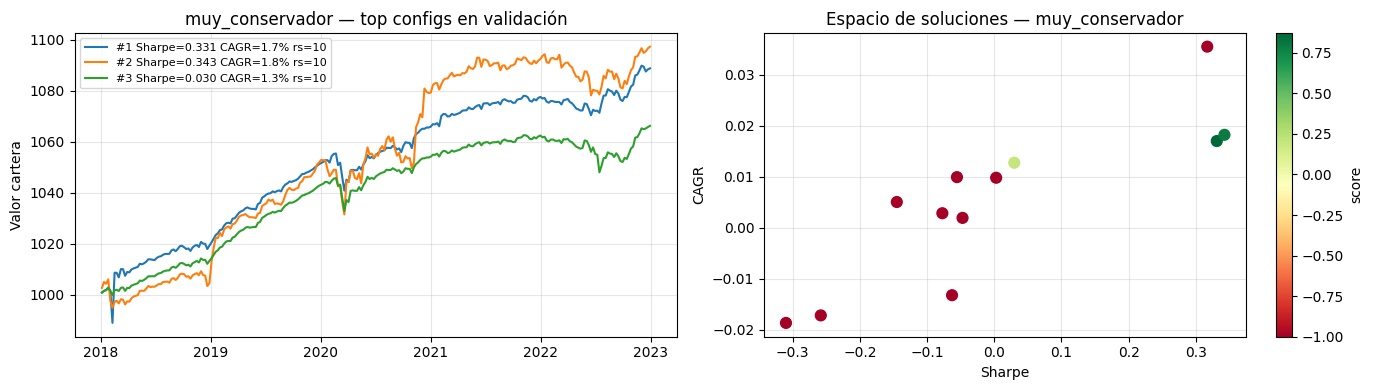

 ranking               config_id    score  reward_scale   sharpe     cagr  max_drawdown  tau  lr_actor  lambda_varianza
       1 muy_conservador_cfg_003 0.873246          10.0 0.331139 0.017004     -0.013856 0.02    0.0001             0.22
       2 muy_conservador_cfg_009 0.800000          10.0 0.342517 0.018225     -0.020320 0.05    0.0001             0.22
       3 muy_conservador_cfg_001 0.200000          10.0 0.029809 0.012749     -0.013713 0.02    0.0001             0.10


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_mc.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_mc and not curvas_mc[cid].empty:
        row = resumen_mc[resumen_mc["config_id"] == cid].iloc[0]
        label = f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%} rs={row['reward_scale']:.0f}"
        ax.plot(curvas_mc[cid].index, curvas_mc[cid].values, lw=1.5, label=label)
ax.set_title("muy_conservador — top configs en validación")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_mc["sharpe"], resumen_mc["cagr"], c=resumen_mc["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR")
ax.set_title("Espacio de soluciones — muy_conservador")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_mc[["ranking", "config_id", "score", "reward_scale", "sharpe", "cagr", "max_drawdown", "tau", "lr_actor", "lambda_varianza"]].head(TOP_K).to_string(index=False))

--- # Fase 2 — conservador (riesgo = 0.30)

In [12]:
perfil_c = "conservador"
resumen_c, curvas_c, agentes_c = run_grid_perfil(perfil_c, PERFILES_RIESGO[perfil_c])


[conservador] Config 1/12 — conservador_cfg_001  (rs=20.0)
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.1 | lambda_correlacion=0.05
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0478  max=-0.0415  media=-1.8879
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -7.7149  (target_entropy=-8.0000)
  residual inicial: 0.2851  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0768
retorno=+0.000030 | pen_total=+0.006327 | reward=-0.006297 | dd=0.3962 | vol=0.020223 | cash=1.000 | riesgo=0.30 || pen_dd=0.000000 | pen_varianza=0.006327 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000000 | 
retorno=-0.048356 | pen_total=+0.033798 | reward=-0.082156 | dd=0.1684 | vol=0.029625 | cash=0.002 | riesgo=0.30 || pen_dd=0.000000 | pen_varianza=0.004636 | pen_correlacion=0.018377 | pen_concentracion=0.010776 | pen_turn=0.000008 | 
retorno=+0.000969 | pen_total=+0.027362 | reward=-0.026419 | dd=0.0098 | vol=0.001914 | cash=0.007 |

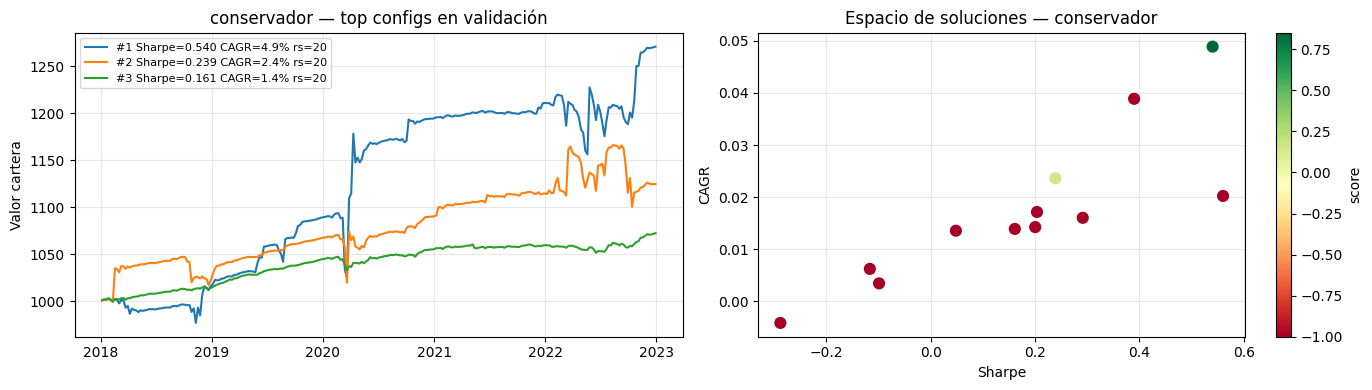

 ranking           config_id  score  reward_scale   sharpe     cagr  max_drawdown  tau  lr_actor  lambda_varianza
       1 conservador_cfg_008   0.85          20.0 0.540264 0.048901     -0.063234 0.05    0.0001             0.15
       2 conservador_cfg_007   0.15          20.0 0.239017 0.023604     -0.056218 0.05    0.0001             0.10
       3 conservador_cfg_001  -1.00          20.0 0.161223 0.013872     -0.013503 0.02    0.0001             0.10


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_c.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_c and not curvas_c[cid].empty:
        row = resumen_c[resumen_c["config_id"] == cid].iloc[0]
        ax.plot(curvas_c[cid].index, curvas_c[cid].values, lw=1.5, label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%} rs={row['reward_scale']:.0f}")
ax.set_title("conservador — top configs en validación")
ax.set_ylabel("Valor cartera"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_c["sharpe"], resumen_c["cagr"], c=resumen_c["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR"); ax.set_title("Espacio de soluciones — conservador"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_c[["ranking", "config_id", "score", "reward_scale", "sharpe", "cagr", "max_drawdown", "tau", "lr_actor", "lambda_varianza"]].head(TOP_K).to_string(index=False))

--- # Fase 3 — normal (riesgo = 0.50)

In [14]:
perfil_n = "normal"
resumen_n, curvas_n, agentes_n = run_grid_perfil(perfil_n, PERFILES_RIESGO[perfil_n])


[normal] Config 1/12 — normal_cfg_001  (rs=10.0)
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.1 | lambda_correlacion=0.1
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0455  max=-0.0427  media=-1.8870
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -7.7149  (target_entropy=-8.0000)
  residual inicial: 0.2851  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0768
retorno=+0.000030 | pen_total=+0.012625 | reward=-0.012595 | dd=0.3962 | vol=0.020223 | cash=1.000 | riesgo=0.50 || pen_dd=0.000000 | pen_varianza=0.012625 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000000 | 
retorno=-0.050450 | pen_total=+0.037227 | reward=-0.087679 | dd=0.1743 | vol=0.030710 | cash=0.002 | riesgo=0.50 || pen_dd=0.000000 | pen_varianza=0.003606 | pen_correlacion=0.024210 | pen_concentracion=0.009405 | pen_turn=0.000005 | 
retorno=+0.001777 | pen_total=+0.025901 | reward=-0.024156 | dd=0.0104 | vol=0.001942 | cash=0.008 | riesgo=0.5

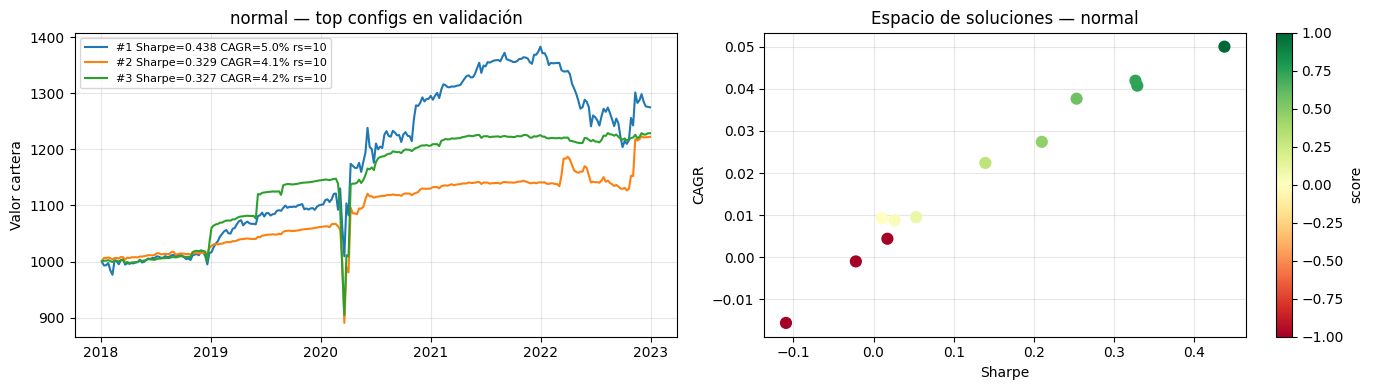

 ranking      config_id    score  reward_scale   sharpe     cagr  max_drawdown  tau  lr_actor  lambda_varianza
       1 normal_cfg_008 1.000000          10.0 0.437989 0.050030     -0.129494 0.05    0.0001             0.15
       2 normal_cfg_010 0.745698          10.0 0.329228 0.040772     -0.165515 0.05    0.0003             0.10
       3 normal_cfg_003 0.740249          10.0 0.326897 0.041942     -0.211885 0.02    0.0001             0.22


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_n.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_n and not curvas_n[cid].empty:
        row = resumen_n[resumen_n["config_id"] == cid].iloc[0]
        ax.plot(curvas_n[cid].index, curvas_n[cid].values, lw=1.5, label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%} rs={row['reward_scale']:.0f}")
ax.set_title("normal — top configs en validación")
ax.set_ylabel("Valor cartera"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_n["sharpe"], resumen_n["cagr"], c=resumen_n["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR"); ax.set_title("Espacio de soluciones — normal"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_n[["ranking", "config_id", "score", "reward_scale", "sharpe", "cagr", "max_drawdown", "tau", "lr_actor", "lambda_varianza"]].head(TOP_K).to_string(index=False))

--- # Fase 4 — arriesgado (riesgo = 0.70)

In [16]:
perfil_a = "arriesgado"
resumen_a, curvas_a, agentes_a = run_grid_perfil(perfil_a, PERFILES_RIESGO[perfil_a])


[arriesgado] Config 1/12 — arriesgado_cfg_001  (rs=20.0)
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.05 | lambda_correlacion=0.05
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0428  max=-0.0433  media=-1.8860
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -7.7149  (target_entropy=-8.0000)
  residual inicial: 0.2851  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0768
retorno=+0.000030 | pen_total=+0.007522 | reward=-0.007492 | dd=0.3962 | vol=0.020223 | cash=1.000 | riesgo=0.70 || pen_dd=0.000000 | pen_varianza=0.007522 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000000 | 
retorno=-0.001523 | pen_total=+0.012645 | reward=-0.014170 | dd=0.0084 | vol=0.004586 | cash=0.002 | riesgo=0.70 || pen_dd=0.000000 | pen_varianza=0.000038 | pen_correlacion=0.006660 | pen_concentracion=0.005945 | pen_turn=0.000003 | 
retorno=-0.015858 | pen_total=+0.007311 | reward=-0.023196 | dd=0.1141 | vol=0.024616 | cash=0.004 | 

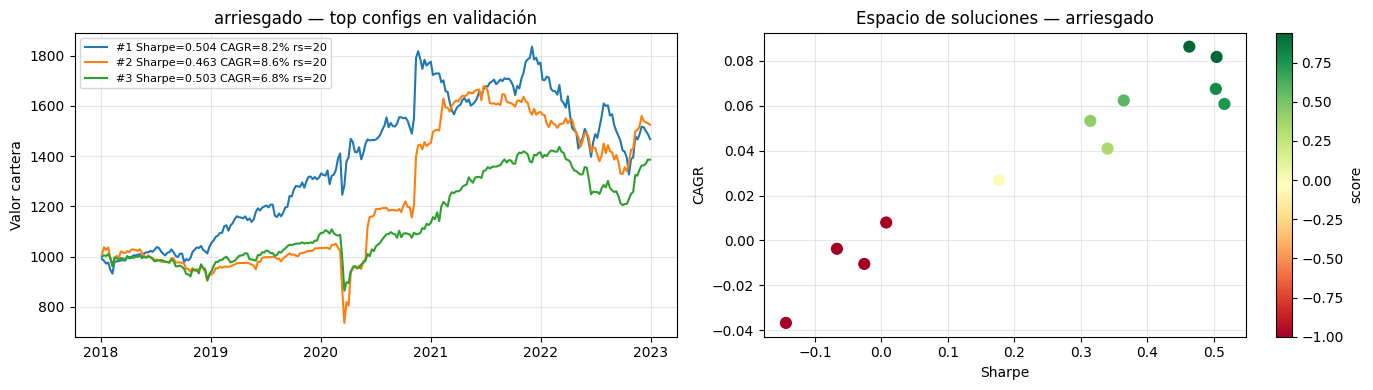

 ranking          config_id    score  reward_scale   sharpe     cagr  max_drawdown  tau  lr_actor  lambda_varianza
       1 arriesgado_cfg_003 0.939947          20.0 0.504369 0.081761     -0.277567 0.02    0.0001             0.15
       2 arriesgado_cfg_006 0.937698          20.0 0.463245 0.086344     -0.300060 0.02    0.0003             0.15
       3 arriesgado_cfg_010 0.794797          20.0 0.503196 0.067513     -0.220533 0.05    0.0003             0.05


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_a.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_a and not curvas_a[cid].empty:
        row = resumen_a[resumen_a["config_id"] == cid].iloc[0]
        ax.plot(curvas_a[cid].index, curvas_a[cid].values, lw=1.5, label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%} rs={row['reward_scale']:.0f}")
ax.set_title("arriesgado — top configs en validación")
ax.set_ylabel("Valor cartera"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_a["sharpe"], resumen_a["cagr"], c=resumen_a["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR"); ax.set_title("Espacio de soluciones — arriesgado"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_a[["ranking", "config_id", "score", "reward_scale", "sharpe", "cagr", "max_drawdown", "tau", "lr_actor", "lambda_varianza"]].head(TOP_K).to_string(index=False))

--- # Fase 5 — muy_arriesgado (riesgo = 0.90)

In [18]:
perfil_ma = "muy_arriesgado"
resumen_ma, curvas_ma, agentes_ma = run_grid_perfil(perfil_ma, PERFILES_RIESGO[perfil_ma])


[muy_arriesgado] Config 1/12 — muy_arriesgado_cfg_001  (rs=20.0)
  tau=0.02 | lr_actor=0.0001 | lr_criticos=0.0003 | lambda_varianza=0.01 | lambda_correlacion=0.02
[DIAGNÓSTICO INICIAL]
  mu: min=-2.0406  max=-0.0438  media=-1.8854
  std: min=0.3679  max=0.3679  media=0.3679
  log_prob: -7.7149  (target_entropy=-8.0000)
  residual inicial: 0.2851  (>0 → alpha sube, <0 → alpha baja)
  accion suma: 1.000000
  peso_cash inicial: 0.0767
retorno=+0.000030 | pen_total=+0.000883 | reward=-0.000853 | dd=0.3962 | vol=0.020223 | cash=1.000 | riesgo=0.90 || pen_dd=0.000000 | pen_varianza=0.000883 | pen_correlacion=0.000000 | pen_concentracion=0.000000 | pen_turn=0.000000 | 
retorno=+0.000014 | pen_total=+0.003243 | reward=-0.003231 | dd=0.0010 | vol=0.002043 | cash=0.003 | riesgo=0.90 || pen_dd=0.000000 | pen_varianza=0.000000 | pen_correlacion=0.000830 | pen_concentracion=0.002410 | pen_turn=0.000002 | 
retorno=+0.001982 | pen_total=+0.000073 | reward=+0.001861 | dd=0.2128 | vol=0.008741 | cash=

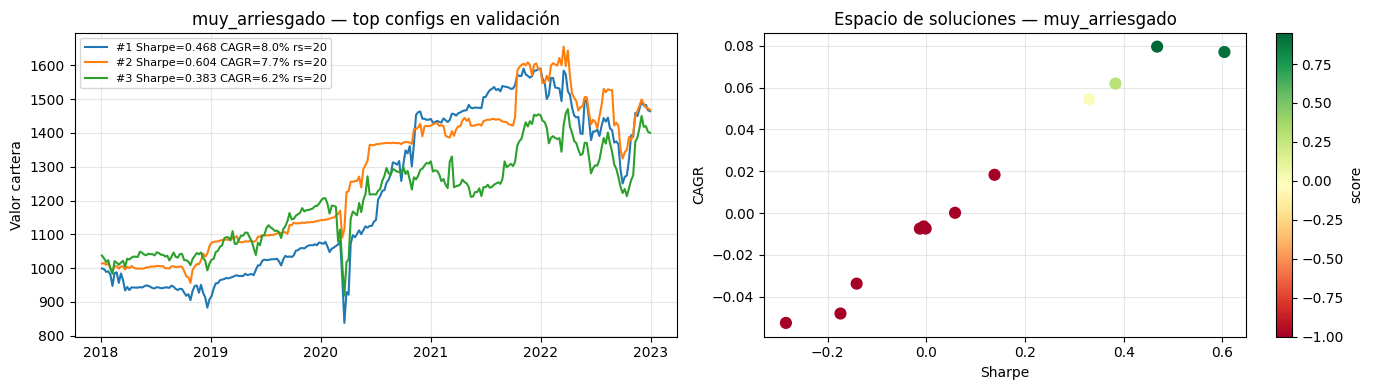

 ranking              config_id    score  reward_scale   sharpe     cagr  max_drawdown  tau  lr_actor  lambda_varianza
       1 muy_arriesgado_cfg_002 0.950273          20.0 0.467555 0.079532     -0.225115 0.02    0.0001             0.03
       2 muy_arriesgado_cfg_008 0.907994          20.0 0.603911 0.076972     -0.200176 0.05    0.0001             0.03
       3 muy_arriesgado_cfg_012 0.285307          20.0 0.383059 0.061889     -0.238891 0.05    0.0003             0.06


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
top_ids = resumen_ma.head(TOP_K)["config_id"].tolist()
for i, cid in enumerate(top_ids):
    if cid in curvas_ma and not curvas_ma[cid].empty:
        row = resumen_ma[resumen_ma["config_id"] == cid].iloc[0]
        ax.plot(curvas_ma[cid].index, curvas_ma[cid].values, lw=1.5, label=f"#{i+1} Sharpe={row['sharpe']:.3f} CAGR={row['cagr']:.1%} rs={row['reward_scale']:.0f}")
ax.set_title("muy_arriesgado — top configs en validación")
ax.set_ylabel("Valor cartera"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
sc = ax.scatter(resumen_ma["sharpe"], resumen_ma["cagr"], c=resumen_ma["score"], cmap="RdYlGn", s=60, zorder=3)
plt.colorbar(sc, ax=ax, label="score")
ax.set_xlabel("Sharpe"); ax.set_ylabel("CAGR"); ax.set_title("Espacio de soluciones — muy_arriesgado"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(resumen_ma[["ranking", "config_id", "score", "reward_scale", "sharpe", "cagr", "max_drawdown", "tau", "lr_actor", "lambda_varianza"]].head(TOP_K).to_string(index=False))

--- # Verificación cruzada de jerarquía

Comprueba que los ganadores de cada perfil mantienen la jerarquía esperada en CAGR y VOL.

In [20]:
ORDEN_PERFILES = ["muy_conservador", "conservador", "normal", "arriesgado", "muy_arriesgado"]

resumenes = {
    "muy_conservador": resumen_mc,
    "conservador":     resumen_c,
    "normal":          resumen_n,
    "arriesgado":      resumen_a,
    "muy_arriesgado":  resumen_ma,
}

ganadores = {}
for perfil in ORDEN_PERFILES:
    best = resumenes[perfil].iloc[0]
    ganadores[perfil] = {
        "config_id":    best["config_id"],
        "reward_scale": best["reward_scale"],
        "score":        best["score"],
        "sharpe":       best["sharpe"],
        "cagr":         best["cagr"],
        "max_drawdown": best["max_drawdown"],
        "vol":          best["vol"],
    }

df_ganadores = pd.DataFrame(ganadores).T[
    ["config_id", "reward_scale", "score", "sharpe", "cagr", "max_drawdown", "vol"]
]
df_ganadores.index.name = "perfil"

print("=" * 80)
print("RESUMEN FINAL — VALIDACIÓN")
print(df_ganadores.to_string(float_format=lambda x: f"{x:.4f}" if abs(x) < 100 else f"{x:.2f}"))

print("\n" + "=" * 80)
print("VERIFICACIÓN DE JERARQUÍAS")
print("-" * 40)

jerarquia_ok = True
for metrica in ["cagr", "vol"]:
    valores = [ganadores[p][metrica] for p in ORDEN_PERFILES]
    violaciones = []
    for i in range(len(ORDEN_PERFILES) - 1):
        p_bajo, p_alto = ORDEN_PERFILES[i], ORDEN_PERFILES[i + 1]
        if not np.isnan(valores[i]) and not np.isnan(valores[i + 1]):
            if valores[i] >= valores[i + 1]:
                violaciones.append(f"{p_bajo} ({valores[i]:.4f}) >= {p_alto} ({valores[i+1]:.4f})")
                jerarquia_ok = False
    if violaciones:
        print(f"  ⚠️  {metrica.upper()} — violaciones:")
        for v in violaciones:
            print(f"       {v}")
    else:
        print(f"  ✅  {metrica.upper()} — jerarquía correcta")

print()
if jerarquia_ok:
    print("✅ Jerarquía completa verificada")
else:
    print("⚠️  Hay violaciones — revisa los lambdas de los perfiles afectados")


RESUMEN FINAL — VALIDACIÓN
                               config_id reward_scale  score sharpe   cagr max_drawdown    vol
perfil                                                                                        
muy_conservador  muy_conservador_cfg_003      10.0000 0.8732 0.3311 0.0170      -0.0139 0.0136
conservador          conservador_cfg_008      20.0000 0.8500 0.5403 0.0489      -0.0632 0.0698
normal                    normal_cfg_008      10.0000 1.0000 0.4380 0.0500      -0.1295 0.0926
arriesgado            arriesgado_cfg_003      20.0000 0.9399 0.5044 0.0818      -0.2776 0.1545
muy_arriesgado    muy_arriesgado_cfg_002      20.0000 0.9503 0.4676 0.0795      -0.2251 0.1663

VERIFICACIÓN DE JERARQUÍAS
----------------------------------------
  ⚠️  CAGR — violaciones:
       arriesgado (0.0818) >= muy_arriesgado (0.0795)
  ✅  VOL — jerarquía correcta

⚠️  Hay violaciones — revisa los lambdas de los perfiles afectados


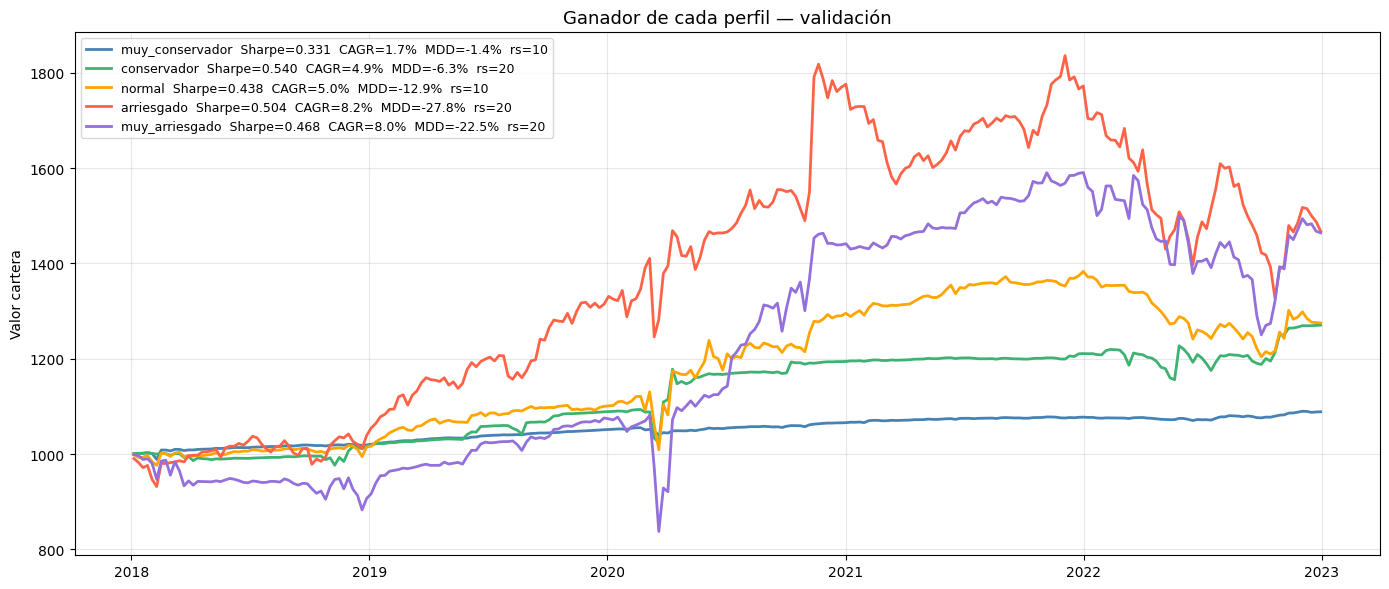

In [21]:
todas_curvas = {
    "muy_conservador": curvas_mc,
    "conservador":     curvas_c,
    "normal":          curvas_n,
    "arriesgado":      curvas_a,
    "muy_arriesgado":  curvas_ma,
}
colores = {
    "muy_conservador": "steelblue",
    "conservador":     "mediumseagreen",
    "normal":          "orange",
    "arriesgado":      "tomato",
    "muy_arriesgado":  "mediumpurple",
}

fig, ax = plt.subplots(figsize=(14, 6))
for perfil in ORDEN_PERFILES:
    best_id = resumenes[perfil].iloc[0]["config_id"]
    serie   = todas_curvas[perfil].get(best_id)
    if serie is not None and not serie.empty:
        g = ganadores[perfil]
        label = (
            f"{perfil}  "
            f"Sharpe={g['sharpe']:.3f}  "
            f"CAGR={g['cagr']:.1%}  "
            f"MDD={g['max_drawdown']:.1%}  "
            f"rs={g['reward_scale']:.0f}"
        )
        ax.plot(serie.index, serie.values, lw=2, color=colores[perfil], label=label)

ax.set_title("Ganador de cada perfil — validación", fontsize=13)
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


--- # Persistencia — guardar configuraciones ganadoras

In [24]:
output_path = PROJECT_ROOT / "config_ganadora_hpo.json"

PARAMS_GUARDAR = [
    "riesgo", "gamma", "tau", "lr_actor", "lr_criticos", "lr_alpha",
    "tamano_batch", "tamano_buffer", "pasos_warmup", "reward_scale",
    "target_entropy", "gamma",
    "lambda_dd", "lambda_varianza", "lambda_correlacion",
]

configs_json: Dict[str, Dict] = {}

for perfil in ORDEN_PERFILES:
    best = resumenes[perfil].iloc[0]
    cfg  = copy.deepcopy(BASE_CONFIG)
    cfg["riesgo"] = float(PERFILES_RIESGO[perfil])

    # Sobrescribir con valores ganadores del grid
    for p in ["tau", "lr_actor", "lr_criticos", "lambda_dd", "lambda_varianza", "lambda_correlacion"]:
        if p in best.index and not pd.isna(best[p]):
            cfg[p] = float(best[p])

    # reward_scale: ganador del grid (ya fue guardado en el resumen)
    cfg["reward_scale"] = float(best["reward_scale"])

    configs_json[perfil] = {
        k: (float(v) if isinstance(v, (np.floating, np.integer, float, int)) else v)
        for k, v in cfg.items()
        if k in PARAMS_GUARDAR
    }
    configs_json[perfil]["_val_sharpe"]       = float(best["sharpe"])
    configs_json[perfil]["_val_cagr"]         = float(best["cagr"])
    configs_json[perfil]["_val_max_drawdown"] = float(best["max_drawdown"])
    configs_json[perfil]["_val_score"]        = float(best["score"])

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(configs_json, f, indent=2, ensure_ascii=False)

print(f"✅ Configuraciones guardadas en: {output_path}")
print()

campos_mostrar = ["riesgo", "reward_scale", "tau", "lr_actor", "lr_criticos",
                  "lambda_dd", "lambda_varianza", "lambda_correlacion",
                  "_val_sharpe", "_val_cagr", "_val_max_drawdown"]
for perfil, cfg in configs_json.items():
    print(f"  [{perfil}]")
    for k in campos_mostrar:
        if k in cfg:
            print(f"    {k:35s} = {cfg[k]}")
    print()


✅ Configuraciones guardadas en: /Users/inigo/Optimizaci-n-din-mica-de-carteras-mediante-Deep-Reinforcement-Learning/config_ganadora_hpo.json

  [muy_conservador]
    riesgo                              = 0.1
    reward_scale                        = 10.0
    tau                                 = 0.02
    lr_actor                            = 0.0001
    lr_criticos                         = 0.0003
    lambda_varianza                     = 0.22
    lambda_correlacion                  = 0.05
    _val_sharpe                         = 0.3311388565837471
    _val_cagr                           = 0.017003994769148045
    _val_max_drawdown                   = -0.013856368758067172

  [conservador]
    riesgo                              = 0.3
    reward_scale                        = 20.0
    tau                                 = 0.05
    lr_actor                            = 0.0001
    lr_criticos                         = 0.0003
    lambda_varianza                     = 0.15
    lambda_corre

In [25]:
print("""
# En Test.py, cargar y reentrenar cada perfil con sus hiperparámetros ganadores:

import json
with open('config_ganadora_hpo.json') as f:
    configs = json.load(f)

for perfil, cfg in configs.items():
    riesgo = cfg['riesgo']
    entorno_full = construir_entorno(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,
    )
    cfg_train = build_train_config({**cfg, 'pasos_totales': 200_000})
    history, agente = entrenar_sac(entorno_full, cfg_train, devolver_agente=True, riesgo=riesgo)
    # ... evaluar en test
""")



# En Test.py, cargar y reentrenar cada perfil con sus hiperparámetros ganadores:

import json
with open('config_ganadora_hpo.json') as f:
    configs = json.load(f)

for perfil, cfg in configs.items():
    riesgo = cfg['riesgo']
    entorno_full = construir_entorno(
        datos_estado=datos_estado_train,
        retornos=retornos_train,
        rf_semanal=rf_semanal_train,
        riesgo=riesgo,
        cfg=cfg,
        covarianzas_iniciales=cov_train,
    )
    cfg_train = build_train_config({**cfg, 'pasos_totales': 200_000})
    history, agente = entrenar_sac(entorno_full, cfg_train, devolver_agente=True, riesgo=riesgo)
    # ... evaluar en test

